# ResNet50 Training on C-NMC 2019 Dataset
This notebook trains a ResNet50 model to classify leukemia cell images.
Dataset: /kaggle/input/c-nmc-2019-dataset


In [17]:
# Install optional packages
!pip -q install torchinfo seaborn

In [18]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torchinfo import summary


In [19]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [20]:
# Dataset path
data_dir = '/kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)'

# Image transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = datasets.ImageFolder(data_dir, transform=transform)
print('Classes:', dataset.classes)

Classes: ['all', 'normal']


In [21]:
# Train/Validation/Test split
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

print(len(train_dataset), len(val_dataset), len(test_dataset))

7462 1599 1600


In [22]:
# Load ResNet50
model = models.resnet50(weights='IMAGENET1K_V1')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(dataset.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

summary(model, input_size=(32,3,224,224))

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 231MB/s]


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 2]                   --
├─Conv2d: 1-1                            [32, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        128
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 256, 56, 56]         --
│    └─Bottleneck: 2-1                   [32, 256, 56, 56]         --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          4,096
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]          --
│ 

In [23]:
# Training function
def train_model(model, train_loader, val_loader, epochs=5):

    train_loss_history=[]
    val_loss_history=[]
    train_acc_history=[]
    val_acc_history=[]

    for epoch in range(epochs):

        model.train()
        running_loss=0
        correct=0
        total=0

        for images,labels in train_loader:

            images=images.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()

            outputs=model(images)
            loss=criterion(outputs,labels)

            loss.backward()
            optimizer.step()

            running_loss+=loss.item()

            _,pred=torch.max(outputs,1)

            total+=labels.size(0)
            correct+=(pred==labels).sum().item()

        train_loss=running_loss/len(train_loader)
        train_acc=100*correct/total

        model.eval()

        val_loss=0
        val_correct=0
        val_total=0

        with torch.no_grad():

            for images,labels in val_loader:

                images=images.to(device)
                labels=labels.to(device)

                outputs=model(images)
                loss=criterion(outputs,labels)

                val_loss+=loss.item()

                _,pred=torch.max(outputs,1)

                val_total+=labels.size(0)
                val_correct+=(pred==labels).sum().item()

        val_loss/=len(val_loader)
        val_acc=100*val_correct/val_total

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Train Acc {train_acc:.2f}% | Val Acc {val_acc:.2f}%")

    return train_loss_history,val_loss_history,train_acc_history,val_acc_history

In [24]:
train_loss_history,val_loss_history,train_acc_history,val_acc_history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=5
)

Epoch 1: Train Loss 0.3125 | Val Loss 0.4695 | Train Acc 87.19% | Val Acc 78.17%
Epoch 2: Train Loss 0.2224 | Val Loss 0.3352 | Train Acc 91.52% | Val Acc 86.49%
Epoch 3: Train Loss 0.1805 | Val Loss 0.1845 | Train Acc 93.17% | Val Acc 93.00%
Epoch 4: Train Loss 0.1429 | Val Loss 0.3264 | Train Acc 94.75% | Val Acc 85.68%
Epoch 5: Train Loss 0.1098 | Val Loss 0.2520 | Train Acc 96.21% | Val Acc 90.37%


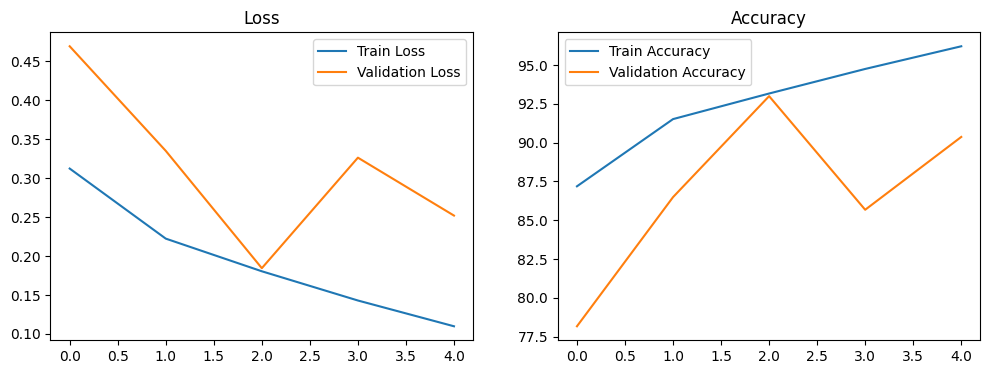

In [25]:
# Plot results
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss_history,label='Train Loss')
plt.plot(val_loss_history,label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(train_acc_history,label='Train Accuracy')
plt.plot(val_acc_history,label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

              precision    recall  f1-score   support

         all       0.93      0.94      0.94      1065
      normal       0.89      0.87      0.88       535

    accuracy                           0.92      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.92      0.92      0.92      1600



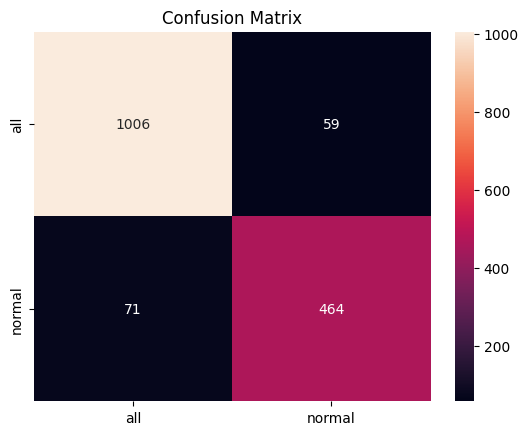

In [26]:
# Test evaluation
model.eval()
y_true=[]
y_pred=[]

with torch.no_grad():
    for images,labels in test_loader:
        images=images.to(device)
        outputs=model(images)
        _,pred=torch.max(outputs,1)

        y_true.extend(labels.numpy())
        y_pred.extend(pred.cpu().numpy())

print(classification_report(y_true,y_pred,target_names=dataset.classes))

cm = confusion_matrix(y_true,y_pred)
sns.heatmap(cm,annot=True,fmt='d',xticklabels=dataset.classes,yticklabels=dataset.classes)
plt.title('Confusion Matrix')
plt.show()